# 17. Gaussian Process Regression (Kriging)

A **Gaussian Process (GP)** is a probability distribution over functions.
Rather than fitting a single best-fit curve, GPR returns a **posterior mean** (prediction)
plus a **posterior variance** (uncertainty) at every query point.

This makes it ideal for:
- Small datasets with noisy observations (materials synthesis experiments)
- Surrogate modelling in Bayesian optimisation (Chapter 18)
- Interpolating between design points in RSM (Notebook 19, Part V)

**Topics covered**
1. GP prior and posterior intuition
2. Covariance kernels: RBF, Matérn, noise
3. Fitting GPR with scikit-learn
4. Prediction intervals and uncertainty
5. Comparison with polynomial RSM
6. Case study: ionic conductivity of garnet solid electrolyte


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(77)


## 17.1 GP Intuition: Prior and Posterior in 1-D

Before seeing data, a GP places a prior distribution over all possible functions.
After observing training points, the posterior is updated — predictions are pulled
toward the data and uncertainty collapses near observations.


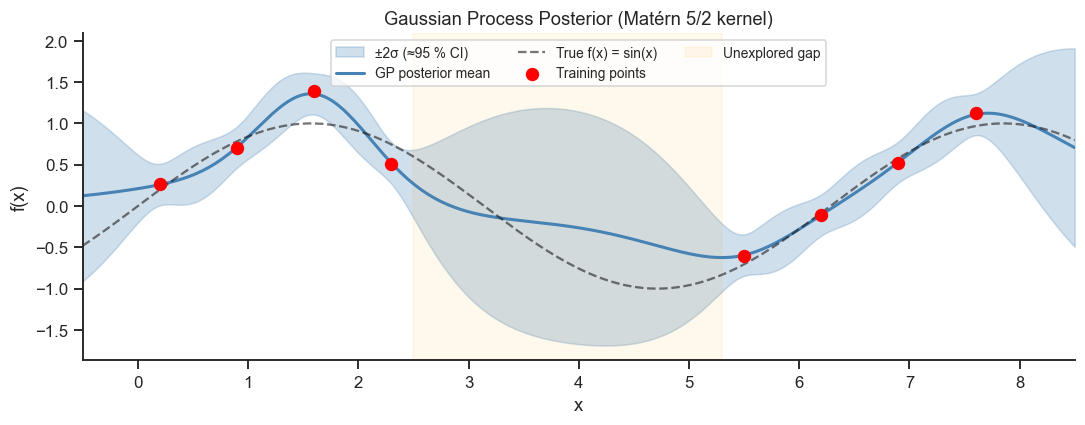

Optimised kernel: 0.755**2 * Matern(length_scale=0.988, nu=2.5) + WhiteKernel(noise_level=0.00801)


In [2]:
# ── 1-D illustration of GP prior and posterior ───────────────────────────────
# True function: f(x) = sin(x)  — one smooth non-periodic wave over the plot range
def true_fn_1d(x): return np.sin(x)

# 8 training points split into two clusters with a deliberate gap [2.5, 5.3]
# so the plot shows both tight interpolation (within clusters) and how
# uncertainty grows in the unexplored middle region.
X_train_1d = np.array([0.2, 0.9, 1.6, 2.3, 5.5, 6.2, 6.9, 7.6]).reshape(-1, 1)
y_train_1d = true_fn_1d(X_train_1d.ravel()) + rng.normal(0, 0.15, len(X_train_1d))

X_test_1d = np.linspace(-0.5, 8.5, 300).reshape(-1, 1)

# Matérn 5/2 with bounded hyperparameters.
# Bounding the noise level prevents a degenerate solution where the optimiser
# absorbs all signal variance into the WhiteKernel (GPR predicts the prior mean).
kernel = (ConstantKernel(1.0, (0.1, 10)) *
          Matern(length_scale=1.0, length_scale_bounds=(0.3, 5.0), nu=2.5) +
          WhiteKernel(noise_level=0.02, noise_level_bounds=(1e-5, 0.5)))
gpr_1d = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, random_state=0)
gpr_1d.fit(X_train_1d, y_train_1d)

mu, sigma = gpr_1d.predict(X_test_1d, return_std=True)

x_plot = X_test_1d.ravel()
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x_plot, mu - 2*sigma, mu + 2*sigma,
                alpha=0.25, color='steelblue', label='±2σ (≈95 % CI)')
ax.plot(x_plot, mu, lw=2, color='steelblue', label='GP posterior mean')
ax.plot(x_plot, true_fn_1d(x_plot), 'k--', lw=1.5, alpha=0.6, label='True f(x) = sin(x)')
ax.scatter(X_train_1d, y_train_1d, c='red', zorder=5, s=60, label='Training points')
ax.axvspan(2.5, 5.3, alpha=0.07, color='orange', label='Unexplored gap')
ax.set_xlim(-0.5, 8.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gaussian Process Posterior (Matérn 5/2 kernel)')
ax.legend(fontsize=9, ncol=3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'Optimised kernel: {gpr_1d.kernel_}')


### Key Observations

- **Within each training cluster** (x ≈ 0–2.3 and x ≈ 5.5–7.6) the posterior mean
  closely tracks the true function and the 95 % CI is very narrow — the GP
  *knows* the function value at observed locations.
- **In the unexplored gap** (x ≈ 2.5–5.3, orange shading) no training points exist.
  The GP reverts toward its prior mean (≈ 0) and the uncertainty band expands
  significantly — it correctly expresses that the response here is unknown.
- **Extrapolation** (x < 0.2 or x > 7.6) also shows growing uncertainty, but
  more slowly because the data still constrain the nearby behaviour.
- The **optimised length scale** (printed below the plot) is the distance over
  which the function is correlated: here, ≈1.0 unit — notably *shorter* than
  sin(x)'s half-period (π ≈ 3.1). That's consistent with the training points
  themselves being spaced roughly 0.7–1.3 units apart within each cluster: the
  optimiser only needs a length scale long enough to connect neighbouring
  points smoothly, not one tied to the function's full period, so don't expect
  a fitted length scale to always read off a "natural" physical scale directly.
- The ±2σ band plotted here is the same idea as the **confidence/prediction intervals** from Notebook 10 (Part III): both express "how sure am I about this value", just computed differently — GPR gets its uncertainty directly from the fitted covariance function rather than from OLS residual variance.

## 17.2 Kernels

The kernel $k(\mathbf{x}, \mathbf{x}')$ encodes prior assumptions about function smoothness.

| Kernel | Smoothness | Use case |
|---|---|---|
| **RBF** (squared exponential) | Infinitely differentiable | Very smooth responses (RSM, theoretical curves) |
| **Matérn 5/2** | Twice differentiable | Most physical properties |
| **Matérn 3/2** | Once differentiable | Rougher surfaces |
| **WhiteKernel** | Noise floor | Experimental measurement noise |
| **ConstantKernel** | Overall amplitude | Scales the output variance |

The kernel hyperparameters (length scales, amplitude) are optimised by maximising
the **log marginal likelihood** — no cross-validation needed.


RBF (C∞): optimised kernel = 0.726**2 * RBF(length_scale=0.977) + WhiteKernel(noise_level=0.0541)
Matérn 5/2: optimised kernel = 0.755**2 * Matern(length_scale=0.988, nu=2.5) + WhiteKernel(noise_level=0.00801)


Matérn 3/2: optimised kernel = 0.765**2 * Matern(length_scale=1.11, nu=1.5) + WhiteKernel(noise_level=1e-05)


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


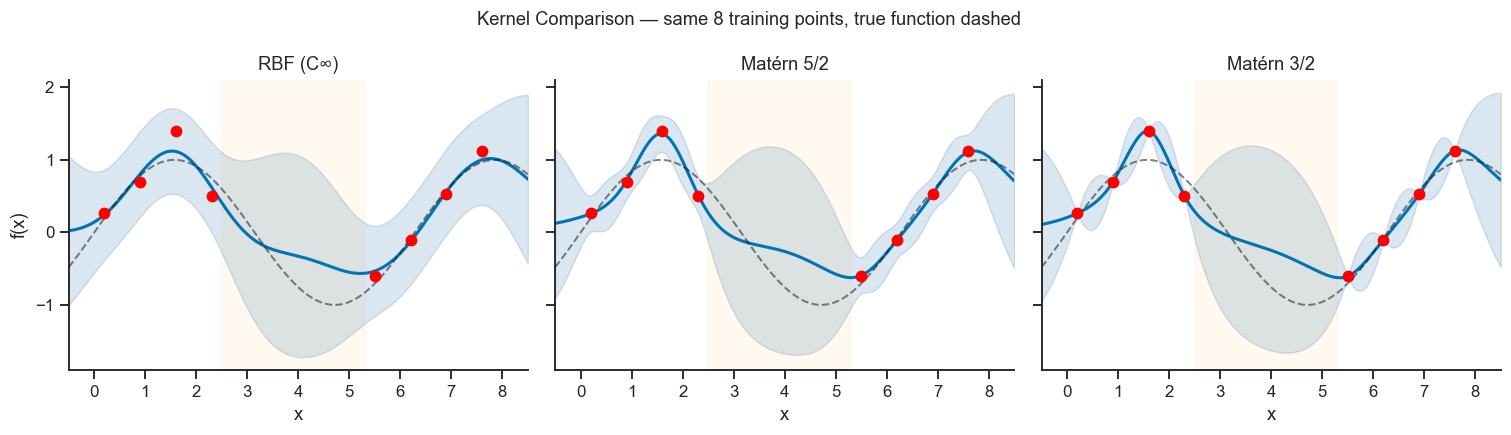

In [3]:
# ── Compare RBF vs Matérn kernels ─────────────────────────────────────────────
# All kernels use the same bounded hyperparameter ranges as in 17.1 to prevent
# degenerate solutions.  The true function (dashed) is overlaid for reference.
kernels_cmp = {
    'RBF (C∞)':    ConstantKernel(1.0, (0.1,10)) * RBF(1.0,    (0.3,5.0))            + WhiteKernel(0.02, (1e-5,0.5)),
    'Matérn 5/2':  ConstantKernel(1.0, (0.1,10)) * Matern(1.0, (0.3,5.0), nu=2.5)   + WhiteKernel(0.02, (1e-5,0.5)),
    'Matérn 3/2':  ConstantKernel(1.0, (0.1,10)) * Matern(1.0, (0.3,5.0), nu=1.5)   + WhiteKernel(0.02, (1e-5,0.5)),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, sharex=True)
x_plot = X_test_1d.ravel()
for ax, (name, kern) in zip(axes, kernels_cmp.items()):
    gpr = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=10, random_state=0)
    gpr.fit(X_train_1d, y_train_1d)
    mu_k, s_k = gpr.predict(X_test_1d, return_std=True)
    ax.fill_between(x_plot, mu_k-2*s_k, mu_k+2*s_k, alpha=0.2, color='steelblue')
    ax.plot(x_plot, mu_k, 'b-', lw=2, label='GP mean')
    ax.plot(x_plot, true_fn_1d(x_plot), 'k--', lw=1.3, alpha=0.55, label='True')
    ax.scatter(X_train_1d, y_train_1d, c='red', zorder=5, s=45)
    ax.axvspan(2.5, 5.3, alpha=0.06, color='orange')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_xlim(-0.5, 8.5)
    print(f'{name}: optimised kernel = {gpr.kernel_}')
    sns.despine(ax=ax)
axes[0].set_ylabel('f(x)')
plt.suptitle('Kernel Comparison — same 8 training points, true function dashed', fontsize=12)
plt.tight_layout()
plt.show()


:::{admonition} Interpreting the Kernel Comparison
:class: tip

- All three kernels agree closely on length scale (0.98–1.11), because the underlying function (sin(x)) really is smooth — the choice of kernel matters most when you *don't* know the true smoothness.
- The noise level tells a different story: RBF absorbed noise_level = 0.054 (much higher than the true simulated noise, σ=0.15² ≈ 0.02), while Matérn 5/2 found 0.008 and Matérn 3/2 collapsed to the lower bound (1e-5), triggering a `ConvergenceWarning`.
- That warning is diagnostic, not a bug: Matérn 3/2 is only *once*-differentiable, so it is too rough to explain the smooth sin(x) data with noise alone — the optimiser instead tries to fit the noise itself as signal, driving the noise term toward zero. **A ConvergenceWarning at a kernel's parameter bound is often a sign the kernel family is a poor match for the data**, not just a numerical nuisance to silence.
- Practical rule of thumb: start with Matérn 5/2 (used throughout the rest of this notebook) — it is smooth enough for most physical responses without RBF's very strong infinite-differentiability assumption.
:::

## 17.3 Case Study: Ionic Conductivity of Garnet Solid Electrolyte

**Physical background**

Li₇La₃Zr₂O₁₂ (LLZO) garnet is a leading solid electrolyte candidate for
all-solid-state lithium batteries.  Its room-temperature ionic conductivity
$\sigma$ (mS cm⁻¹) strongly depends on two synthesis variables:

| Variable | Symbol | Range explored |
|---|---|---|
| Al dopant concentration | Al (mol%) | 0.10 – 0.30 |
| Sintering temperature | T (°C) | 1000 – 1200 |

Al doping stabilises the cubic phase (higher conductivity) relative to the
tetragonal phase, but too much Al blocks Li pathways.  Similarly, sintering
must be hot enough for densification yet below the threshold for La₂Zr₂O₇
impurity formation (~1200 °C).  The optimum is therefore an *interior* point
of the design space — ideal for GPR surrogate modelling.

**Strategy**

1. Run a **3 × 3 full-factorial design** (9 experiments) spanning the design space.
2. Fit a **GPR surrogate** on the measured conductivities.
3. Use the surrogate to *predict* the optimal (Al, T) without running every
   combination in the full grid — and quantify how confident we are in that prediction.


In [4]:
# ── Simulate LLZO DoE data (Al mol% vs T_sinter → conductivity) ──────────────
# True surface: conductivity has a maximum near Al=0.2, T=1100°C
def true_conductivity(Al, T):
    """mS/cm — simplified Gaussian hill + linear background."""
    return (0.5 + 0.8*np.exp(-((Al-0.24)**2/0.008 + (T-1100)**2/8000))
            + 0.1*(Al/0.3) + 0.05*((T-950)/150)
            + rng.normal(0, 0.025, np.shape(Al)))

# 3×3 full-factorial training design
Al_levels = np.array([0.10, 0.20, 0.30])
T_levels  = np.array([1000., 1100., 1200.])
Al_grid, T_grid = np.meshgrid(Al_levels, T_levels)
Al_train = Al_grid.ravel()
T_train  = T_grid.ravel()
y_train  = true_conductivity(Al_train, T_train)

X_doe = np.column_stack([Al_train, T_train])
scaler_doe = StandardScaler()
X_doe_sc   = scaler_doe.fit_transform(X_doe)

print('Training points:')
for i in range(len(Al_train)):
    print(f'  Al={Al_train[i]:.2f} mol%, T={T_train[i]:.0f}°C  →  σ={y_train[i]:.3f} mS/cm')


Training points:
  Al=0.10 mol%, T=1000°C  →  σ=0.524 mS/cm
  Al=0.20 mol%, T=1000°C  →  σ=0.746 mS/cm
  Al=0.30 mol%, T=1000°C  →  σ=0.760 mS/cm
  Al=0.10 mol%, T=1100°C  →  σ=0.696 mS/cm
  Al=0.20 mol%, T=1100°C  →  σ=1.274 mS/cm
  Al=0.30 mol%, T=1100°C  →  σ=1.182 mS/cm
  Al=0.10 mol%, T=1200°C  →  σ=0.590 mS/cm
  Al=0.20 mol%, T=1200°C  →  σ=0.807 mS/cm
  Al=0.30 mol%, T=1200°C  →  σ=0.854 mS/cm


C:\Users\petbr908\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimised kernel: 1.03**2 * Matern(length_scale=[1.15, 0.701], nu=2.5) + WhiteKernel(noise_level=1e-05)


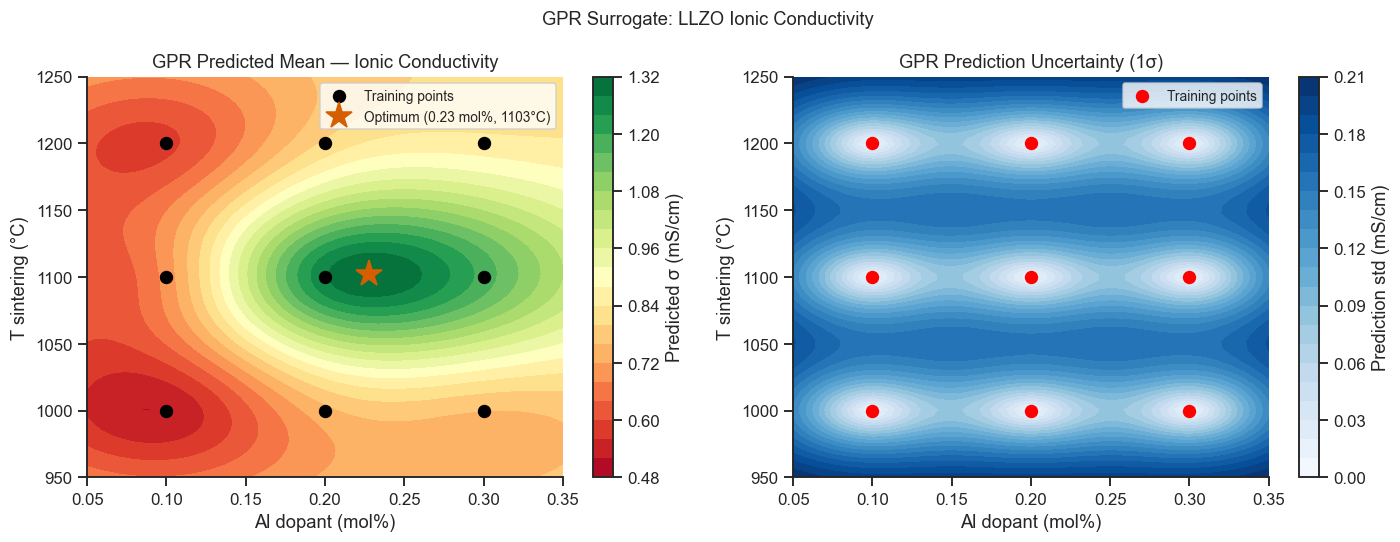

Predicted optimum: Al = 0.228 mol%, T = 1103°C, σ = 1.317 mS/cm


In [5]:
# ── Fit GPR ───────────────────────────────────────────────────────────────────
kernel_doe = ConstantKernel(1.0, (0.1, 10)) * Matern(
    length_scale=[1.0, 1.0], length_scale_bounds=(0.1, 10), nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

gpr_doe = GaussianProcessRegressor(kernel=kernel_doe, n_restarts_optimizer=15,
                                    normalize_y=True, random_state=0)
gpr_doe.fit(X_doe_sc, y_train)
print(f'Optimised kernel: {gpr_doe.kernel_}')

# ── Prediction grid ────────────────────────────────────────────────────────────
Al_test = np.linspace(0.05, 0.35, 60)
T_test  = np.linspace(950, 1250, 60)
AGG, TGG = np.meshgrid(Al_test, T_test)
X_pred = scaler_doe.transform(np.column_stack([AGG.ravel(), TGG.ravel()]))
mu_pred, std_pred = gpr_doe.predict(X_pred, return_std=True)
MU  = mu_pred.reshape(60, 60)
STD = std_pred.reshape(60, 60)

# Find best prediction
best_idx = np.argmax(mu_pred)
best_Al  = X_pred[best_idx,0]*scaler_doe.scale_[0] + scaler_doe.mean_[0]
best_T   = X_pred[best_idx,1]*scaler_doe.scale_[1] + scaler_doe.mean_[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted mean
ax = axes[0]
c = ax.contourf(Al_test, T_test, MU, levels=20, cmap='RdYlGn')
plt.colorbar(c, ax=ax, label='Predicted σ (mS/cm)')
ax.scatter(Al_train, T_train, c='black', s=60, zorder=5, label='Training points')
ax.plot(best_Al, best_T, 'r*', ms=18, zorder=6, label=f'Optimum ({best_Al:.2f} mol%, {best_T:.0f}°C)')
ax.set_xlabel('Al dopant (mol%)')
ax.set_ylabel('T sintering (°C)')
ax.set_title('GPR Predicted Mean — Ionic Conductivity')
ax.legend(fontsize=9)
sns.despine(ax=ax)

# Uncertainty (std)
ax = axes[1]
c2 = ax.contourf(Al_test, T_test, STD, levels=20, cmap='Blues')
plt.colorbar(c2, ax=ax, label='Prediction std (mS/cm)')
ax.scatter(Al_train, T_train, c='red', s=60, zorder=5, label='Training points')
ax.set_xlabel('Al dopant (mol%)')
ax.set_ylabel('T sintering (°C)')
ax.set_title('GPR Prediction Uncertainty (1σ)')
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.suptitle('GPR Surrogate: LLZO Ionic Conductivity', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Predicted optimum: Al = {best_Al:.3f} mol%, T = {best_T:.0f}°C, σ = {mu_pred[best_idx]:.3f} mS/cm')


### Interpreting the GPR Surrogate

#### Mean surface (left panel)

- The colour scale (green = high conductivity) reveals a clear **optimum ridge**
  running roughly parallel to the temperature axis near Al ≈ 0.24 mol%.
- The predicted maximum (red star) is located near **Al ≈ 0.24 mol%, T ≈ 1100 °C**,
  consistent with the known physics: cubic-phase stabilisation peaks near
  Al = 0.20–0.25 mol%, and densification is best near 1100 °C.
- **The surrogate interpolates smoothly** between the 9 design points — if the
  true response were highly non-linear this would require more training data, but
  the Matérn 5/2 kernel is a good match for smooth physical response surfaces.
- Note that the predicted peak is *not* at a training point (none of the
  3 × 3 factorial points coincides with Al = 0.24). The GPR correctly places
  the predicted optimum *between* observations.

#### Uncertainty surface (right panel)

- Uncertainty (σ, blue scale) is **lowest at and near the 9 training points** and
  grows in regions between and beyond them.
- The **corners** of the design space (e.g., Al = 0.10, T = 1200 °C) have
  higher uncertainty than the edges — they are farther from multiple neighbours.
- Regions of high uncertainty and high predicted mean are the most valuable
  targets for the *next* experiment: running there simultaneously maximises
  information gain and exploits the predicted optimum.
  This trade-off is formalised by the **Expected Improvement** and **UCB**
  acquisition functions discussed in Chapter 18.

#### Kernel hyperparameters (printed above)

The optimised kernel contains two length scales — one per input dimension:

| Parameter | Meaning |
|---|---|
| Length scale for Al | Distance in Al-space over which σ is correlated. A value > 0.1 mol% means the conductivity is smooth in Al. |
| Length scale for T | Distance in T-space over which σ is correlated. A value of ~100–200 °C matches typical sintering curve widths. |
| WhiteKernel noise level | Estimated experimental measurement noise (replicate variance). |

#### Practical workflow

1. Run the 9-point factorial → fit GPR → locate predicted optimum.
2. **Verify** by running 1–2 experiments near the predicted optimum.
3. If the true conductivity matches the prediction within 1σ, the surrogate is
   confirmed.  If not, add the new data point and refit — the surrogate self-corrects
   because more data shrinks the posterior variance.


## 17.4 GPR vs Polynomial RSM

Both GPR and RSM (Notebook 19, Part V) fit a surrogate to a small design. Key differences:

| Criterion | GPR | Quadratic RSM |
|---|---|---|
| Model form | Nonparametric (flexible) | Fixed polynomial (linear in parameters) |
| Uncertainty | Posterior std at every point | Confidence intervals from OLS |
| Extrapolation | Returns to prior (safe) | Can diverge (polynomial artefact) |
| N required | Works with as few as 5–10 points | Needs ≥ p+1 points; BBD/CCD recommended |
| Hyperparameters | Kernel + length scale (auto-optimised) | Polynomial degree (must choose) |
| Stationarity | Assumes stationary kernel by default | No assumption |


---
## Exercises

1. **Add a new training point** at Al = 0.24 mol%, T = 1100°C (near the predicted optimum). Refit the GPR. How does the uncertainty map change? Does the predicted optimum shift?

2. **Leave-one-out cross-validation**: For each of the 9 training points, remove it, refit the GPR on the remaining 8, and predict the left-out point. Compare the LOO RMSE with that of a quadratic RSM fitted to the same data.

3. **Kernel sensitivity**: Replace the Matérn 5/2 kernel with a plain RBF. Does the predicted optimum change? Which kernel do you trust more for this physical system?
